In [1]:
# @title Installation and Imports
!pip install -q transformers
from sklearn.model_selection import train_test_split
import tensorflow as tf
import pandas as pd
import numpy as np
from transformers import AutoTokenizer, TFAutoModelForSequenceClassification
import tensorflow_datasets as tfds
import os
import matplotlib.pyplot as plt
from google.colab import drive

In [2]:
# @title Configuration and Setup
# Set random seeds for reproducibility
tf.random.set_seed(42)
np.random.seed(42)

# Define Arabic labels for sentiment
labels = ['سلبي', 'إيجابي']  # ['Negative', 'Positive']

# Use AraBERT model
model_name = "aubmindlab/bert-base-arabertv2"
tokenizer = AutoTokenizer.from_pretrained(model_name)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/611 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/384 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/720k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.31M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

In [3]:
# @title CUDA-Optimized Hyperparameters
# CUDA-OPTIMIZED HYPERPARAMETERS
max_length = 64   # Optimal for CUDA GPU memory
batch_size = 32   # Optimal batch size for GPU utilization (increase to 64 if you have V100/A100)
learning_rate = 2e-5  # Standard fine-tuning rate for BERT
weight_decay = 0.01
num_epochs = 3        # Usually sufficient with good data
warmup_steps = 100    # Warmup helps with stability

# Adjust batch size based on available GPU memory
if tf.config.list_physical_devices('GPU'):
    # Try to detect GPU type and adjust batch size accordingly
    try:
        gpu_memory = tf.config.experimental.get_memory_info('GPU:0')['current'] / 1024**3
        if gpu_memory > 15:  # V100/A100 (16GB+)
            batch_size = 64
            print(f"🚀 High-memory GPU detected, using batch size: {batch_size}")
        elif gpu_memory > 10:  # T4 (16GB)
            batch_size = 32
            print(f"🚀 Standard GPU detected, using batch size: {batch_size}")
        else:  # Smaller GPUs
            batch_size = 16
            print(f"⚠️  Limited GPU memory, using batch size: {batch_size}")
    except:
        batch_size = 32  # Default for most GPUs
        print(f"🔧 Using default GPU batch size: {batch_size}")
else:
    batch_size = 8  # Conservative for CPU
    max_length = 32  # Shorter sequences for CPU
    print(f"🐌 CPU detected, using optimized settings: batch_size={batch_size}, max_length={max_length}")

⚠️  Limited GPU memory, using batch size: 16


In [4]:
# @title Text Processing Functions
def convert_example_to_feature(text):
    """Convert text to BERT features with improved error handling"""
    if not isinstance(text, str):
        text = "" if text is None else str(text)

    # Clean the text
    text = text.strip()
    if not text:
        text = "لا يوجد نص"  # "No text" in Arabic

    return tokenizer.encode_plus(
        text,
        add_special_tokens=True,
        max_length=max_length,
        padding='max_length',
        truncation=True,
        return_attention_mask=True,
        return_token_type_ids=True,
    )

def map_example_to_dict(input_ids, attention_masks, token_type_ids, label):
    return {
        "input_ids": input_ids,
        "token_type_ids": token_type_ids,
        "attention_mask": attention_masks,
    }, label

In [6]:
# @title Data Loading and Preprocessing
# Load and preprocess data
drive.mount('/content/drive')
data_path = '/content/ar_reviews_100k.tsv'

try:
    # Load with explicit column names since your file has 'label' first, then 'text'
    df = pd.read_csv(data_path, sep='\t', names=['label_orig', 'text'], header=0)
    print(f"Dataset loaded successfully with {len(df)} rows")
    print(f"Column names: {df.columns.tolist()}")

    # Data cleaning and validation
    text_column = 'text'
    label_column = 'label_orig'

    # Remove rows with missing or empty text
    initial_count = len(df)
    df = df.dropna(subset=[text_column, label_column])
    df = df[df[text_column].str.strip() != '']
    df = df[df[label_column].str.strip() != '']

    print(f"Removed {initial_count - len(df)} rows with missing/empty data")

    # Convert labels to binary and verify distribution
    print(f"\nOriginal label distribution:")
    print(df[label_column].value_counts())

    # Clean label values (remove any extra whitespace)
    df[label_column] = df[label_column].str.strip()

    # IMPORTANT FIX: Handle 3-class dataset properly
    # Option 1: Remove "Mixed" samples to create clean binary classification
    print(f"\nRemoving 'Mixed' samples for binary classification...")
    df_binary = df[df[label_column].isin(['Positive', 'Negative'])].copy()
    print(f"Samples after removing Mixed: {len(df_binary)}")

    # Convert to binary labels
    df_binary['label'] = df_binary[label_column].apply(lambda x: 1 if x == 'Positive' else 0)

    # Use the cleaned binary dataset
    df = df_binary.copy()

    # Check label distribution after conversion
    label_counts = df['label'].value_counts()
    print(f"\nCleaned binary label distribution:")
    print(f"Negative (0): {label_counts.get(0, 0)}")
    print(f"Positive (1): {label_counts.get(1, 0)}")

    # Verify the conversion worked correctly
    print(f"\nLabel conversion verification:")
    sample_labels = df.head(10)[[label_column, 'label']]
    print(sample_labels)

    # Show some sample texts to verify Arabic content
    print(f"\nSample Arabic texts:")
    for i, text in enumerate(df[text_column].head(3)):
        print(f"{i+1}. {text[:100]}...")
        print(f"   Label: {df.iloc[i][label_column]} -> {df.iloc[i]['label']}")
        print()

    # Ultra-optimized dataset for very fast training
    if len(df) > 10000:
        # Even smaller dataset for CPU training
        max_per_class = 5000 if not tf.config.list_physical_devices('GPU') else 10000
        negative_samples = df[df['label'] == 0].sample(n=min(max_per_class, len(df[df['label'] == 0])), random_state=42)
        positive_samples = df[df['label'] == 1].sample(n=min(max_per_class, len(df[df['label'] == 1])), random_state=42)
        df = pd.concat([negative_samples, positive_samples]).sample(frac=1, random_state=42).reset_index(drop=True)

        hardware = "GPU" if tf.config.list_physical_devices('GPU') else "CPU"
        print(f"Ultra-optimized dataset to {len(df)} rows for {hardware} training")

        # Check new distribution
        label_counts = df['label'].value_counts()
        print(f"Final balanced label distribution:")
        print(f"Negative (0): {label_counts.get(0, 0)}")
        print(f"Positive (1): {label_counts.get(1, 0)}")
    else:
        # If dataset is smaller, just shuffle
        df = df.sample(frac=1, random_state=42).reset_index(drop=True)
        print(f"Using full dataset: {len(df)} rows")

    texts = df[text_column].values
    labels_array = df['label'].values

    print(f"\nFinal dataset info:")
    print(f"Total samples: {len(texts)}")
    print(f"Text column: '{text_column}'")
    print(f"Sample text length (chars): min={min(len(str(t)) for t in texts)}, max={max(len(str(t)) for t in texts)}, avg={np.mean([len(str(t)) for t in texts]):.1f}")

    # IMPROVED DATA SPLITTING
    # First split: 70% train, 30% temp
    train_texts, temp_texts, train_labels, temp_labels = train_test_split(
        texts, labels_array, test_size=0.3, random_state=42, stratify=labels_array
    )

    # Second split: 15% validation, 15% test from the 30% temp
    val_texts, test_texts, val_labels, test_labels = train_test_split(
        temp_texts, temp_labels, test_size=0.5, random_state=42, stratify=temp_labels
    )

    print(f"\nImproved data split:")
    print(f"Training: {len(train_texts)} samples ({len(train_texts)/len(df)*100:.1f}%)")
    print(f"  - Negative: {sum(train_labels == 0)} ({sum(train_labels == 0)/len(train_labels)*100:.1f}%)")
    print(f"  - Positive: {sum(train_labels == 1)} ({sum(train_labels == 1)/len(train_labels)*100:.1f}%)")
    print(f"Validation: {len(val_texts)} samples ({len(val_texts)/len(df)*100:.1f}%)")
    print(f"  - Negative: {sum(val_labels == 0)} ({sum(val_labels == 0)/len(val_labels)*100:.1f}%)")
    print(f"  - Positive: {sum(val_labels == 1)} ({sum(val_labels == 1)/len(val_labels)*100:.1f}%)")
    print(f"Test: {len(test_texts)} samples ({len(test_texts)/len(df)*100:.1f}%)")
    print(f"  - Negative: {sum(test_labels == 0)} ({sum(test_labels == 0)/len(test_labels)*100:.1f}%)")
    print(f"  - Positive: {sum(test_labels == 1)} ({sum(test_labels == 1)/len(test_labels)*100:.1f}%)")

except Exception as e:
    print(f"Error loading data: {e}")
    exit(1)

Mounted at /content/drive
Dataset loaded successfully with 99999 rows
Column names: ['label_orig', 'text']
Removed 0 rows with missing/empty data

Original label distribution:
label_orig
Positive    33333
Mixed       33333
Negative    33333
Name: count, dtype: int64

Removing 'Mixed' samples for binary classification...
Samples after removing Mixed: 66666

Cleaned binary label distribution:
Negative (0): 33333
Positive (1): 33333

Label conversion verification:
  label_orig  label
0   Positive      1
1   Positive      1
2   Positive      1
3   Positive      1
4   Positive      1
5   Positive      1
6   Positive      1
7   Positive      1
8   Positive      1
9   Positive      1

Sample Arabic texts:
1. ممتاز نوعا ما . النظافة والموقع والتجهيز والشاطيء. المطعم...
   Label: Positive -> 1

2. أحد أسباب نجاح الإمارات أن كل شخص في هذه الدولة يعشق ترابها. نحن نحب الإمارات. ومضات من فكر. نصائح ل...
   Label: Positive -> 1

3. هادفة .. وقوية. تنقلك من صخب شوارع القاهرة الى هدوء جبال الشيشان .. 

In [7]:
# @title Dataset Creation Function
def create_dataset_from_arrays(texts, labels_array, shuffle=False):
    """Create TensorFlow dataset with improved error handling and performance optimization"""
    input_ids_list = []
    token_type_ids_list = []
    attention_mask_list = []
    label_list = []

    print(f"Processing {len(texts)} samples...")
    skipped = 0

    for i, (text, label) in enumerate(zip(texts, labels_array)):
        if i % 1000 == 0:
            print(f"  Processed {i}/{len(texts)} samples")

        if not isinstance(text, str) or not text.strip():
            skipped += 1
            continue

        try:
            bert_input = convert_example_to_feature(text)
            input_ids_list.append(bert_input['input_ids'])
            token_type_ids_list.append(bert_input['token_type_ids'])
            attention_mask_list.append(bert_input['attention_mask'])
            # FIX: Remove the extra list wrapper - label should be scalar
            label_list.append(label)  # Changed from [label] to label
        except Exception as e:
            print(f"Error processing text: {text[:50]}... Error: {e}")
            skipped += 1

    if skipped > 0:
        print(f"Skipped {skipped} problematic samples")

    print(f"Creating TensorFlow dataset...")
    dataset = tf.data.Dataset.from_tensor_slices(
        (input_ids_list, attention_mask_list, token_type_ids_list, label_list)
    ).map(map_example_to_dict, num_parallel_calls=tf.data.AUTOTUNE)

    if shuffle:
        dataset = dataset.shuffle(buffer_size=min(5000, len(input_ids_list)))

    # Optimize dataset performance
    dataset = dataset.batch(batch_size, drop_remainder=False)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)

    return dataset

In [8]:
# @title Create Training Datasets
# Create datasets
print("Creating datasets...")
ds_train = create_dataset_from_arrays(train_texts, train_labels, shuffle=True)
ds_val = create_dataset_from_arrays(val_texts, val_labels, shuffle=False)
ds_test = create_dataset_from_arrays(test_texts, test_labels, shuffle=False)

# Debug: Check dataset shapes
print("Debugging dataset structure...")
for batch in ds_train.take(1):
    inputs, labels = batch
    print(f"Input shapes:")
    for key, value in inputs.items():
        print(f"  {key}: {value.shape}")
    print(f"Labels shape: {labels.shape}")
    print(f"Labels dtype: {labels.dtype}")
    print(f"Sample labels: {labels[:3].numpy()}")
    break

Creating datasets...
Processing 14000 samples...
  Processed 0/14000 samples
  Processed 1000/14000 samples
  Processed 2000/14000 samples
  Processed 3000/14000 samples
  Processed 4000/14000 samples
  Processed 5000/14000 samples
  Processed 6000/14000 samples
  Processed 7000/14000 samples
  Processed 8000/14000 samples
  Processed 9000/14000 samples
  Processed 10000/14000 samples
  Processed 11000/14000 samples
  Processed 12000/14000 samples
  Processed 13000/14000 samples
Creating TensorFlow dataset...
Processing 3000 samples...
  Processed 0/3000 samples
  Processed 1000/3000 samples
  Processed 2000/3000 samples
Creating TensorFlow dataset...
Processing 3000 samples...
  Processed 0/3000 samples
  Processed 1000/3000 samples
  Processed 2000/3000 samples
Creating TensorFlow dataset...
Debugging dataset structure...
Input shapes:
  input_ids: (16, 64)
  token_type_ids: (16, 64)
  attention_mask: (16, 64)
Labels shape: (16,)
Labels dtype: <dtype: 'int32'>
Sample labels: [1 1 0]


In [9]:
# @title Model Loading and Configuration
# IMPROVED MODEL CONFIGURATION WITH EXPLICIT CUDA PLACEMENT
print("Loading model...")

# Load model on CUDA GPU if available
device_name = '/GPU:0' if tf.config.list_physical_devices('GPU') else '/CPU:0'
print(f"Loading model on device: {device_name}")

with tf.device(device_name):
    # Option 1: Load model and configure dropout
    try:
        model = TFAutoModelForSequenceClassification.from_pretrained(
            model_name,
            num_labels=2,
        )

        # Configure dropout in the model's config
        if hasattr(model.config, 'hidden_dropout_prob'):
            model.config.hidden_dropout_prob = 0.1
        if hasattr(model.config, 'attention_probs_dropout_prob'):
            model.config.attention_probs_dropout_prob = 0.1

        print(f"✅ Model loaded successfully on {device_name}")
        print(f"   Hidden dropout: {getattr(model.config, 'hidden_dropout_prob', 'N/A')}")

    except Exception as e:
        print(f"Error loading model with config: {e}")
        print("Trying alternative approach...")

        # Option 2: Load model with custom config
        from transformers import AutoConfig

        config = AutoConfig.from_pretrained(model_name)
        config.num_labels = 2
        if hasattr(config, 'hidden_dropout_prob'):
            config.hidden_dropout_prob = 0.1
        if hasattr(config, 'attention_probs_dropout_prob'):
            config.attention_probs_dropout_prob = 0.1

        model = TFAutoModelForSequenceClassification.from_pretrained(
            model_name,
            config=config
        )
        print("✅ Model loaded with custom config successfully.")

Loading model...
Loading model on device: /GPU:0


model.safetensors:   0%|          | 0.00/543M [00:00<?, ?B/s]

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFBertForSequenceClassification: ['bert.embeddings.position_ids']
- This IS expected if you are initializing TFBertForSequenceClassification from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFBertForSequenceClassification from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
Some weights or buffers of the TF 2.0 model TFBertForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['classifier.weight', 'classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✅ Model loaded successfully on /GPU:0
   Hidden dropout: 0.1


In [10]:
# @title Optimizer and Loss Configuration
# IMPROVED OPTIMIZER WITH WEIGHT DECAY
optimizer = tf.keras.optimizers.AdamW(
    learning_rate=learning_rate,
    weight_decay=weight_decay,
    epsilon=1e-8,
    beta_1=0.9,
    beta_2=0.999,
)

# Loss and metrics with class weighting for imbalanced data
from sklearn.utils.class_weight import compute_class_weight

# Calculate class weights to handle imbalanced data
unique_labels = np.unique(train_labels)
class_weights = compute_class_weight('balanced', classes=unique_labels, y=train_labels)
class_weight_dict = dict(zip(unique_labels, class_weights))
print(f"Class weights: {class_weight_dict}")

# FIXED: Use proper loss and metrics for binary classification
loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)

# Use simpler metrics to avoid shape issues
metrics = [
    tf.keras.metrics.SparseCategoricalAccuracy(name='accuracy'),
]

model.compile(optimizer=optimizer, loss=loss, metrics=metrics)

# Print model summary to verify architecture
print(f"\nModel summary:")
print(f"Model type: {type(model).__name__}")
print(f"Number of parameters: {model.count_params():,}")
if hasattr(model, 'summary'):
    try:
        model.summary()
    except:
        print("Could not display detailed model summary")

model.compile(optimizer=optimizer, loss=loss, metrics=metrics)

Class weights: {np.int64(0): np.float64(1.0), np.int64(1): np.float64(1.0)}

Model summary:
Model type: TFBertForSequenceClassification
Number of parameters: 135,194,882
Model: "tf_bert_for_sequence_classification"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 bert (TFBertMainLayer)      multiple                  135193344 
                                                                 
 dropout_37 (Dropout)        multiple                  0 (unused)
                                                                 
 classifier (Dense)          multiple                  1538      
                                                                 
Total params: 135194882 (515.73 MB)
Trainable params: 135194882 (515.73 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [11]:
# @title Training Callbacks Setup
# OPTIMIZED CALLBACKS FOR FASTER TRAINING
callbacks = [
    # More aggressive early stopping for faster training
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=1,  # Reduced patience for faster stopping
        restore_best_weights=True,
        verbose=1,
        min_delta=0.01  # Larger min_delta
    ),

    # Model checkpoint
    tf.keras.callbacks.ModelCheckpoint(
        filepath='best_arabic_sentiment_model',
        save_best_only=True,
        monitor='val_accuracy',
        mode='max',
        verbose=1
    ),

    # Learning rate reduction for faster convergence
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,  # More aggressive reduction
        patience=1,  # Faster reduction
        min_lr=1e-7,
        verbose=1
    ),
]

print("Starting optimized training...")

Starting optimized training...


In [12]:
# @title CUDA GPU Configuration and Hardware Check
# EXPLICIT CUDA GPU CONFIGURATION
print("Configuring CUDA GPU...")

# Check for CUDA-capable GPUs
gpus = tf.config.list_physical_devices('GPU')
print(f"Physical GPUs detected: {len(gpus)}")
for i, gpu in enumerate(gpus):
    print(f"  GPU {i}: {gpu}")

# Check if TensorFlow was built with CUDA support
print(f"TensorFlow built with CUDA: {tf.test.is_built_with_cuda()}")
print(f"CUDA GPUs available to TensorFlow: {tf.test.is_gpu_available()}")

if not gpus:
    print("❌ NO CUDA GPU DETECTED!")
    print("🔧 SOLUTION: In Google Colab:")
    print("   1. Runtime → Change Runtime Type")
    print("   2. Hardware Accelerator → GPU (T4, V100, or A100)")
    print("   3. Click Save → Runtime will restart")
    print("   4. Re-run this notebook")
    print("\n⚠️  Current setup will use CPU (VERY SLOW: ~3+ hours)")
    print("⚡ With CUDA GPU: ~10-15 minutes")

    # Continue with CPU-optimized settings
    print("\n🐌 Continuing with CPU-optimized settings...")

elif gpus:
    print("✅ CUDA GPU DETECTED! Configuring for optimal performance...")

    try:
        # Configure GPU memory growth to prevent OOM
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
            print(f"✅ Memory growth enabled for {gpu}")

        # Set GPU as visible device
        tf.config.experimental.set_visible_devices(gpus[0], 'GPU')

        # Enable mixed precision for faster training (if supported)
        try:
            from tensorflow.keras import mixed_precision
            policy = mixed_precision.Policy('mixed_float16')
            mixed_precision.set_global_policy(policy)
            print("✅ Mixed precision (FP16) enabled for faster training")
        except:
            print("⚠️  Mixed precision not available, using FP32")

        # Verify GPU is being used
        with tf.device('/GPU:0'):
            test_tensor = tf.constant([[1.0, 2.0, 3.0]])
            print(f"✅ Test tensor created on: {test_tensor.device}")

    except RuntimeError as e:
        print(f"⚠️  GPU configuration warning: {e}")

# Display current device configuration
print(f"\nCurrent TensorFlow device configuration:")
print(f"  Available devices: {[device.name for device in tf.config.list_logical_devices()]}")

# Calculate expected training time based on hardware
total_batches = len(list(ds_train))
print(f"\nTraining configuration:")
print(f"  Total batches per epoch: {total_batches}")
print(f"  Batch size: {batch_size}")
print(f"  Sequence length: {max_length}")

if gpus and tf.test.is_gpu_available():
    time_per_batch = 0.2  # seconds on CUDA GPU
    print(f"🚀 Expected time per epoch (CUDA GPU): ~{total_batches * time_per_batch / 60:.1f} minutes")
    print(f"🚀 Expected total training time (CUDA GPU): ~{total_batches * time_per_batch * num_epochs / 60:.1f} minutes")
else:
    time_per_batch = 15  # seconds on CPU
    print(f"🐌 Expected time per epoch (CPU): ~{total_batches * time_per_batch / 60:.1f} minutes")
    print(f"🐌 Expected total training time (CPU): ~{total_batches * time_per_batch * num_epochs / 60:.1f} minutes")
    print("⚠️  STRONGLY RECOMMEND ENABLING CUDA GPU!")

print("\n" + "="*60)
print("STARTING TRAINING...")
print("="*60)

Instructions for updating:
Use `tf.config.list_physical_devices('GPU')` instead.


Configuring CUDA GPU...
Physical GPUs detected: 1
  GPU 0: PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')
TensorFlow built with CUDA: True
CUDA GPUs available to TensorFlow: True
✅ CUDA GPU DETECTED! Configuring for optimal performance...
⚠️  GPU configuration warning: Physical devices cannot be modified after being initialized

Current TensorFlow device configuration:
  Available devices: ['/device:CPU:0', '/device:GPU:0']

Training configuration:
  Total batches per epoch: 875
  Batch size: 16
  Sequence length: 64
🚀 Expected time per epoch (CUDA GPU): ~2.9 minutes
🚀 Expected total training time (CUDA GPU): ~8.8 minutes

STARTING TRAINING...


Training model on CUDA GPU...
Epoch 1/3
875/875 [==============================] - ETA: 0s - loss: 0.1497 - accuracy: 0.9462
Epoch 1: val_accuracy improved from 0.88000 to 0.88267, saving model to best_arabic_sentiment_model
875/875 [==============================] - 275s 314ms/step - loss: 0.1497 - accuracy: 0.9462 - val_loss: 0.3252 - val_accuracy: 0.8827 - lr: 4.0000e-06
Epoch 2/3
875/875 [==============================] - ETA: 0s - loss: 0.1122 - accuracy: 0.9609
Epoch 2: val_accuracy did not improve from 0.88267

Epoch 2: ReduceLROnPlateau reducing learning rate to 8.000000093488779e-07.
875/875 [==============================] - 231s 264ms/step - loss: 0.1122 - accuracy: 0.9609 - val_loss: 0.3607 - val_accuracy: 0.8813 - lr: 4.0000e-06
Epoch 2: early stopping
Restoring model weights from the end of the best epoch: 1.


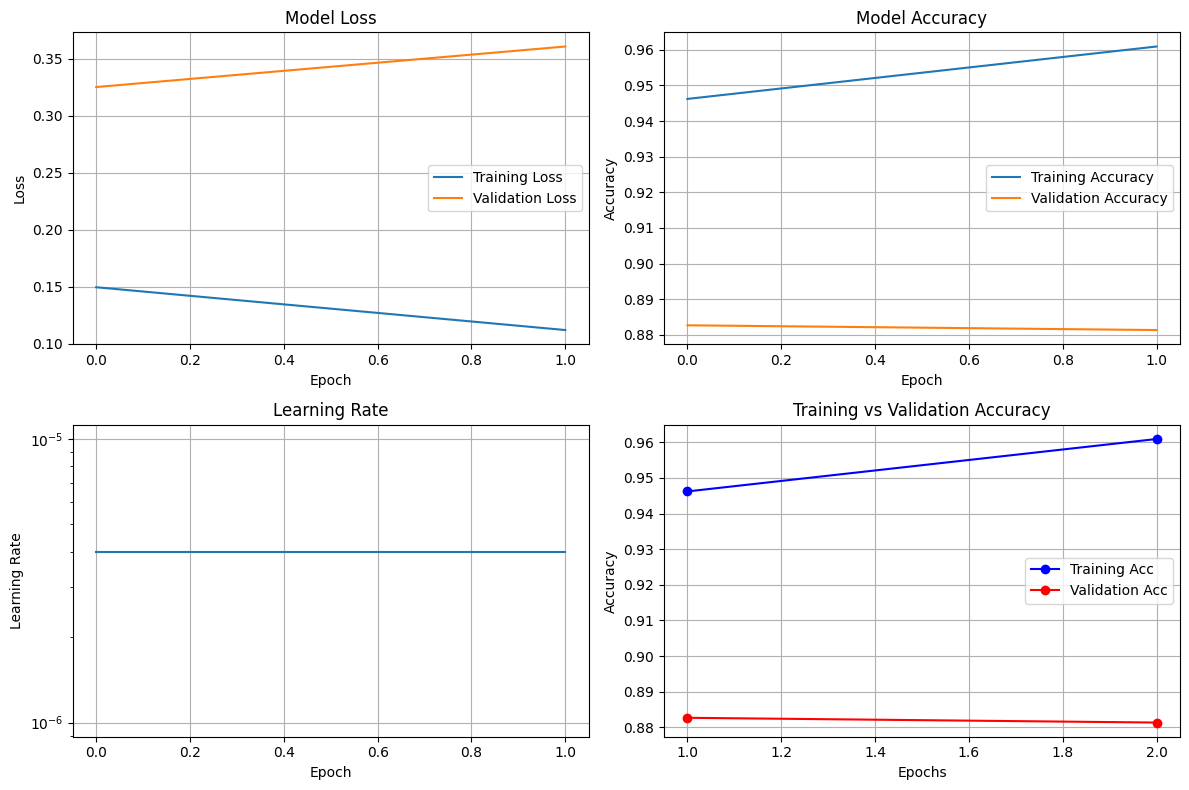


FINAL EVALUATION
Validation Loss: 0.3252
Validation Accuracy: 0.8827

Test Loss: 0.3651
Test Accuracy: 0.8760

Overfitting Analysis:
Best Training Accuracy: 0.9609
Best Validation Accuracy: 0.8827
Test Accuracy: 0.8760
⚠️  WARNING: Possible overfitting detected (train-val gap > 5%)
✅ Good validation-test consistency


In [14]:
# @title Model Training
# ------------------------------------------------------------------------------
# MODEL TRAINING (FINE-TUNING)
# ------------------------------------------------------------------------------
# This is where the actual fine-tuning happens

try:
    print("Training model on CUDA GPU..." if tf.config.list_physical_devices('GPU') else "Training model on CPU...")

    # Train the model with explicit device placement
    with tf.device(device_name):
        history = model.fit(
            ds_train,                      # Training dataset
            epochs=num_epochs,             # Number of epochs (3)
            validation_data=ds_val,        # Validation dataset for monitoring
            callbacks=callbacks,           # Training callbacks
            class_weight=class_weight_dict, # Handle class imbalance
            verbose=1                      # Print training progress
        )

    # IMPROVED PLOTTING
    plt.figure(figsize=(12, 8))

    # Plot loss
    plt.subplot(2, 2, 1)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    # Plot accuracy
    plt.subplot(2, 2, 2)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    # Plot learning rate (if available)
    if 'lr' in history.history:
        plt.subplot(2, 2, 3)
        plt.plot(history.history['lr'])
        plt.title('Learning Rate')
        plt.xlabel('Epoch')
        plt.ylabel('Learning Rate')
        plt.yscale('log')
        plt.grid(True)

    # Plot training vs validation accuracy comparison
    plt.subplot(2, 2, 4)
    epochs = range(1, len(history.history['accuracy']) + 1)
    plt.plot(epochs, history.history['accuracy'], 'bo-', label='Training Acc')
    plt.plot(epochs, history.history['val_accuracy'], 'ro-', label='Validation Acc')
    plt.title('Training vs Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

    # Save the model
    model.save_pretrained("arabic_sentiment_model")
    tokenizer.save_pretrained("arabic_sentiment_tokenizer")

    # COMPREHENSIVE EVALUATION
    print("\n" + "="*50)
    print("FINAL EVALUATION")
    print("="*50)

    # Evaluate on validation set
    val_evaluation = model.evaluate(ds_val, verbose=0)
    print(f"Validation Loss: {val_evaluation[0]:.4f}")
    print(f"Validation Accuracy: {val_evaluation[1]:.4f}")

    # Evaluate on test set
    test_evaluation = model.evaluate(ds_test, verbose=0)
    print(f"\nTest Loss: {test_evaluation[0]:.4f}")
    print(f"Test Accuracy: {test_evaluation[1]:.4f}")

    # Check for overfitting
    train_acc = max(history.history['accuracy'])
    val_acc = max(history.history['val_accuracy'])
    test_acc = test_evaluation[1]

    print(f"\nOverfitting Analysis:")
    print(f"Best Training Accuracy: {train_acc:.4f}")
    print(f"Best Validation Accuracy: {val_acc:.4f}")
    print(f"Test Accuracy: {test_acc:.4f}")

    if train_acc - val_acc > 0.05:
        print("⚠️  WARNING: Possible overfitting detected (train-val gap > 5%)")
    else:
        print("✅ Good generalization (train-val gap < 5%)")

    if abs(val_acc - test_acc) > 0.03:
        print("⚠️  WARNING: Validation-test gap > 3%")
    else:
        print("✅ Good validation-test consistency")

except Exception as e:
    print(f"Error during training: {e}")

In [15]:
# @title Main Prediction Function
# COMPLETELY REWRITTEN PREDICTION FUNCTION - FIXES TENSOR HASHING
def predict_sentiment(text, return_probabilities=False):
    """
    Predict sentiment for Arabic text - FIXED VERSION

    Args:
        text (str): Arabic text to analyze
        return_probabilities (bool): Whether to return class probabilities

    Returns:
        dict: Prediction results
    """
    if not isinstance(text, str) or not text.strip():
        return {
            'text': text,
            'error': 'Invalid or empty text',
            'sentiment': None,
            'confidence': 0.0
        }

    try:
        # Step 1: Tokenize the input text
        inputs = tokenizer.encode_plus(
            text,
            add_special_tokens=True,
            max_length=max_length,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_token_type_ids=True,
            return_tensors='tf'
        )

        # Step 2: Prepare input dictionary for the model
        model_inputs = {
            'input_ids': inputs['input_ids'],
            'attention_mask': inputs['attention_mask'],
            'token_type_ids': inputs['token_type_ids']
        }

        # Step 3: Get model predictions (avoid .logits which may cause issues)
        with tf.device('/GPU:0' if tf.config.list_physical_devices('GPU') else '/CPU:0'):
            predictions = model(model_inputs, training=False)

            # Extract logits and immediately convert to numpy
            logits_numpy = predictions.logits.numpy()

            # Apply softmax manually using numpy (avoids TensorFlow tensor issues)
            exp_logits = np.exp(logits_numpy - np.max(logits_numpy, axis=1, keepdims=True))
            probabilities = exp_logits / np.sum(exp_logits, axis=1, keepdims=True)
            probabilities = probabilities[0]  # Get first (and only) sample

        # Step 4: Get prediction results - FIXED LABEL MAPPING
        predicted_class_idx = int(np.argmax(probabilities))
        confidence = float(probabilities[predicted_class_idx] * 100)

        # FIXED: Map class index to correct sentiment label
        # Class 0 = Negative (سلبي), Class 1 = Positive (إيجابي)
        if predicted_class_idx == 0:
            predicted_sentiment = 'سلبي'  # Negative
        else:
            predicted_sentiment = 'إيجابي'  # Positive

        # Step 5: Build result dictionary
        result = {
            'text': text,
            'sentiment': predicted_sentiment,
            'confidence': confidence,
            'predicted_class': predicted_class_idx,  # Added for debugging
            'sentiment_scores': {
                'سلبي': float(probabilities[0] * 100),  # Negative (class 0)
                'إيجابي': float(probabilities[1] * 100)   # Positive (class 1)
            }
        }

        if return_probabilities:
            result['probabilities'] = probabilities.tolist()

        return result

    except Exception as e:
        # More detailed error reporting
        import traceback
        error_details = traceback.format_exc()
        return {
            'text': text,
            'error': f'Prediction error: {str(e)}',
            'error_details': error_details,
            'sentiment': None,
            'confidence': 0.0
        }

In [16]:
# @title Alternative Simple Prediction Function
# ALTERNATIVE SIMPLE PREDICTION FUNCTION
def predict_sentiment_simple(text):
    """
    Simplified prediction function using dataset format
    """
    try:
        # Create a single-sample dataset using the same format as training
        inputs = convert_example_to_feature(text)

        # Convert to tensors
        input_ids = tf.constant([inputs['input_ids']], dtype=tf.int32)
        attention_mask = tf.constant([inputs['attention_mask']], dtype=tf.int32)
        token_type_ids = tf.constant([inputs['token_type_ids']], dtype=tf.int32)

        # Create input dictionary
        model_input = {
            'input_ids': input_ids,
            'attention_mask': attention_mask,
            'token_type_ids': token_type_ids
        }

        # Get prediction
        prediction = model(model_input, training=False)
        logits = prediction.logits.numpy()[0]

        # Manual softmax
        exp_logits = np.exp(logits - np.max(logits))
        probabilities = exp_logits / np.sum(exp_logits)

        predicted_class_idx = int(np.argmax(probabilities))
        confidence = float(probabilities[predicted_class_idx] * 100)

        # FIXED: Correct label mapping
        if predicted_class_idx == 0:
            predicted_sentiment = 'سلبي'  # Negative
        else:
            predicted_sentiment = 'إيجابي'  # Positive

        return {
            'text': text,
            'sentiment': predicted_sentiment,
            'confidence': confidence,
            'predicted_class': predicted_class_idx,  # Added for debugging
            'probabilities': {
                'سلبي': float(probabilities[0] * 100),    # Negative (class 0)
                'إيجابي': float(probabilities[1] * 100)     # Positive (class 1)
            }
        }

    except Exception as e:
        return {
            'text': text,
            'error': f'Simple prediction error: {str(e)}',
            'sentiment': None,
            'confidence': 0.0
        }

In [17]:
# @title Testing Both Prediction Functions
# TEST WITH BOTH FUNCTIONS
print("\n" + "="*50)
print("TESTING BOTH PREDICTION FUNCTIONS")
print("="*50)

arabic_examples = [
    "الفيلم كان سيئ جدا ومضيعة للوقت",  # Should be Negative
    "أنا سعيد جدًا بهذا المنتج، يعمل بشكل ممتاز",  # Should be Positive
    "الخدمة في هذا المطعم بطيئة للغاية",  # Should be Negative
    "هذا المكان رائع وأنصح الجميع بزيارته",  # Should be Positive
    "الطعام لذيذ والأسعار معقولة",  # Should be Positive
]

print("🔧 TESTING MAIN PREDICTION FUNCTION:")
print("-" * 50)
for i, example in enumerate(arabic_examples):
    result = predict_sentiment(example)
    if 'error' not in result:
        print(f"{i+1}. Text: {example}")
        print(f"   Sentiment: {result['sentiment']} (Confidence: {result['confidence']:.2f}%)")
        print(f"   Scores: Negative={result['sentiment_scores']['سلبي']:.1f}%, Positive={result['sentiment_scores']['إيجابي']:.1f}%")
    else:
        print(f"{i+1}. ERROR: {result['error']}")
    print()

print("\n🔄 TESTING ALTERNATIVE SIMPLE FUNCTION:")
print("-" * 50)
for i, example in enumerate(arabic_examples):
    result = predict_sentiment_simple(example)
    if 'error' not in result:
        print(f"{i+1}. Text: {example}")
        print(f"   Sentiment: {result['sentiment']} (Confidence: {result['confidence']:.2f}%)")
        print(f"   Scores: Negative={result['probabilities']['سلبي']:.1f}%, Positive={result['probabilities']['إيجابي']:.1f}%")
    else:
        print(f"{i+1}. ERROR: {result['error']}")
    print()

print("\n✅ Training completed successfully!")
print("📊 Check the plots above to verify that overfitting has been minimized.")
print("💾 Model saved to 'arabic_sentiment_model' directory.")


TESTING BOTH PREDICTION FUNCTIONS
🔧 TESTING MAIN PREDICTION FUNCTION:
--------------------------------------------------
1. Text: الفيلم كان سيئ جدا ومضيعة للوقت
   Sentiment: سلبي (Confidence: 99.51%)
   Scores: Negative=99.5%, Positive=0.5%

2. Text: أنا سعيد جدًا بهذا المنتج، يعمل بشكل ممتاز
   Sentiment: إيجابي (Confidence: 98.63%)
   Scores: Negative=1.4%, Positive=98.6%

3. Text: الخدمة في هذا المطعم بطيئة للغاية
   Sentiment: سلبي (Confidence: 87.02%)
   Scores: Negative=87.0%, Positive=13.0%

4. Text: هذا المكان رائع وأنصح الجميع بزيارته
   Sentiment: إيجابي (Confidence: 98.82%)
   Scores: Negative=1.2%, Positive=98.8%

5. Text: الطعام لذيذ والأسعار معقولة
   Sentiment: إيجابي (Confidence: 93.55%)
   Scores: Negative=6.4%, Positive=93.6%


🔄 TESTING ALTERNATIVE SIMPLE FUNCTION:
--------------------------------------------------
1. Text: الفيلم كان سيئ جدا ومضيعة للوقت
   Sentiment: سلبي (Confidence: 99.51%)
   Scores: Negative=99.5%, Positive=0.5%

2. Text: أنا سعيد جدًا بهذا 